# Sandbox - Likelihood

This notebook is used to prototype the likelihood function, used to generate all scenarios of use of the algorithm.

---

## Imports & Config

In [1]:
! pwd

/home/slejoly/Projects/mimosa/tests/identifiability


In [2]:
! export XLA_PYTHON_CLIENT_MEM_FRACTION=.9

In [3]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [4]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [5]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)
import jax.random as jr
import jax.numpy as jnp
from jax import vmap, jit, Array, grad

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

import numpy as np

from kernax import ZeroMean, ConstantMean, LinearMean, AffineMean
from kernax import SEKernel, VarianceKernel, sample_hps_from_uniform_priors, BatchModule, config
#config.parameter_transform = "exp"

In [6]:
# Local imports
from mimosa.sampling import sample_gp
from likelihood_comps import *

INFO:2026-03-06 16:48:21,224:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-06 16:48:21,224 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [7]:
key = jr.PRNGKey(42)
jax.devices()

[CudaDevice(id=0)]

---

## GP identifiability - SE without noise

In [8]:
sample_jitter = jnp.array(1e-10)
nll_jitter = jnp.array(1e-3)

In [9]:
grid_range = (-25, 25)
nb_points = 25
grid = jnp.linspace(*grid_range, nb_points)[:, None]

In [10]:
kern_priors = {"variance":(1., 5.), "length_scale": (.5, 2.)}

### M samples

In [11]:
nb_tasks = 25

In [12]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
key, subkey = jr.split(key)
kern = sample_hps_from_uniform_priors(subkey, kern, kern_priors)
kern = BatchModule(kern, batch_size=nb_tasks, batch_in_axes=None, batch_over_inputs=False)  # Same HPs in each kernel
mean = ZeroMean()
print(f"{kern}\n{mean}")

VarianceKernel(variance=3.20) * SEKernel(length_scale=1.13)
ZeroMean()


In [13]:
key, subkey = jax.random.split(key)
tasks = sample_gp(subkey, mean(grid), kern(grid), jitter=sample_jitter)
tasks.shape

(25, 25)

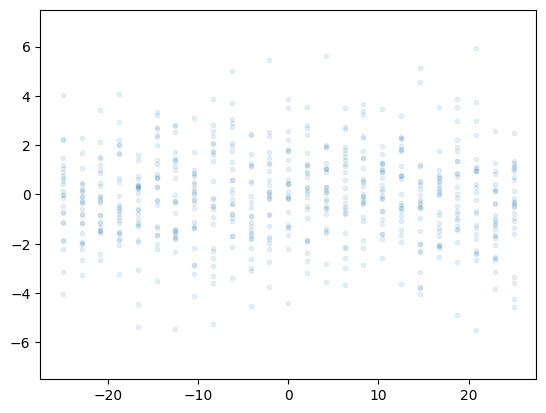

In [14]:
# Plot the sample
plt.scatter(jnp.broadcast_to(grid.T, tasks.shape), tasks, marker=".", alpha=.1)
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-max(kern_priors["variance"])*1.5, max(kern_priors["variance"])*1.5)
plt.show()

In [15]:
emp_var = jnp.mean((tasks - mean(grid)) ** 2)  # Variance around true mean
emp_var

Array(3.35789141, dtype=float64)

In [16]:
jnp.var(tasks)  # Variance around empirical mean

Array(3.34780147, dtype=float64)

In [17]:
lss = jnp.exp(jnp.linspace(jnp.log(0.1), jnp.log(2.5), 100))
vrs = jnp.exp(jnp.linspace(jnp.log(0.75), jnp.log(7.0), 100))

In [18]:
llh_from_hps = jit(lambda l, v:
                   vmap(lambda t:
                        mvn_nll(
	                        grid,
	                        t[:, None],
	                        mean(grid)[None, :],
	                        (VarianceKernel(variance=v) * SEKernel(length_scale=l))(grid)[None, :, :],
	                        jitter=nll_jitter).squeeze())(tasks).mean())

In [19]:
llh_values = vmap(vmap(llh_from_hps, in_axes=(0, None)), in_axes=(None, 0))(lss, vrs)
llh_grads =  vmap(vmap(grad(llh_from_hps, argnums=(0, 1)), in_axes=(0, None)), in_axes=(None, 0))(lss, vrs)
llh_values.shape, llh_grads[0].shape,  llh_grads[1].shape

((100, 100), (100, 100), (100, 100))

In [20]:
orig_var = kern.inner.left.variance.item()
orig_ls = kern.inner.right.length_scale.item()
v_opt, l_opt = jnp.unravel_index(jnp.argmin(llh_values), llh_values.shape)

In [21]:
orig_ls, lss[l_opt].item(), orig_var, vrs[v_opt].item(), emp_var.item()

(1.1309826013678217,
 1.1456328578240762,
 3.195029507840844,
 3.400562795948333,
 3.357891411881438)

In [22]:
llh_values[v_opt, l_opt]

Array(50.20231101, dtype=float64)

In [23]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['LLH values', 'length_scale grads', 'variance grads'],
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}],],
    horizontal_spacing=0.05,
    vertical_spacing=0.1,
)

# --- VALUES ---

fig.add_trace(go.Surface(x=lss, y=vrs, z=np.asarray(llh_values), showscale=False, colorscale='Viridis'), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[orig_ls], y=[orig_var], z=[llh_from_hps(orig_ls, orig_var)],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[lss[l_opt].item()], y=[vrs[v_opt].item()], z=[llh_values[v_opt, l_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Kernel optimal (var={vrs[v_opt].item():.2f}, ls={lss[l_opt].item():.2f})',
    showlegend=False,
), row=1, col=1)

# --- GRADS (ls) ---

fig.add_trace(go.Surface(x=lss, y=vrs, z=np.asarray(llh_grads[0]), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Surface(x=lss, y=vrs, z=np.asarray(jnp.zeros_like(llh_grads[0])), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[orig_ls], y=[orig_var], z=[grad(llh_from_hps, argnums=(0, 1))(orig_ls, orig_var)[0]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[lss[l_opt].item()], y=[vrs[v_opt].item()], z=[llh_grads[0][v_opt, l_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Kernel optimal (var={vrs[v_opt].item():.2f}, ls={lss[l_opt].item():.2f})',
    showlegend=False,
), row=1, col=2)

# --- GRADS (var) ---

fig.add_trace(go.Surface(x=lss, y=vrs, z=np.asarray(llh_grads[1]), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Surface(x=lss, y=vrs, z=np.asarray(jnp.zeros_like(llh_grads[1])), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[orig_ls], y=[orig_var], z=[grad(llh_from_hps, argnums=(0, 1))(orig_ls, orig_var)[1]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[lss[l_opt].item()], y=[vrs[v_opt].item()], z=[llh_grads[1][v_opt, l_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Kernel optimal (var={vrs[v_opt].item():.2f}, ls={lss[l_opt].item():.2f})',
    showlegend=False,
), row=1, col=3)

fig.update_layout(
    title='NLL values and grads',
    scene =dict(xaxis_title='length_scale', yaxis_title='variance', zaxis_title='NLL values', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene2=dict(xaxis_title='length_scale', yaxis_title='variance', zaxis_title='NLL grads - length-scale', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene3=dict(xaxis_title='length_scale', yaxis_title='variance', zaxis_title='NLL grads - variance', xaxis_autorange='reversed', yaxis_autorange='reversed'),
	height=700
)

fig.show()

### Multi-task, Multi-sample

In [24]:
nb_samples = 500
key, subkey_1, subkey_2 = jr.split(key, 3)

In [25]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
kern = BatchModule(kern, batch_size=nb_tasks, batch_in_axes=None, batch_over_inputs=False)  # Same HPs in each kernel
kern = BatchModule(kern, batch_size=nb_samples, batch_in_axes=0, batch_over_inputs=False)  # Distinct HPs in each kernel
kern = sample_hps_from_uniform_priors(subkey_1, kern, kern_priors)
mean = ZeroMean()
print(f"{kern}\n{mean}")

VarianceKernel(variance=[3.06 ± 1.15]₅₀₀) * SEKernel(length_scale=[1.26 ± 0.43]₅₀₀)
ZeroMean()


In [26]:
subkeys = jr.split(subkey_2, nb_samples)
samples = vmap(lambda k, cov: sample_gp(k, mean(grid), cov, jitter=sample_jitter))(subkeys, kern(grid))
samples.shape

(500, 25, 25)

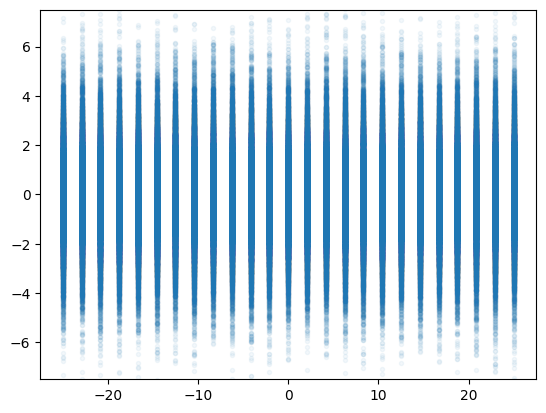

In [27]:
# Plot the sample
plt.scatter(jnp.broadcast_to(grid.T, samples.shape), samples, marker=".", alpha=0.05)
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-max(kern_priors["variance"])*1.5, max(kern_priors["variance"])*1.5)
plt.show()

In [28]:
full_emp_var = jnp.mean(jnp.mean((samples - mean(grid)[None, :])**2, axis=1))  # Full variance around original mean
full_emp_var

Array(3.0625153, dtype=float64)

In [29]:
jnp.var(samples)  # Full variance around empirical mean

Array(3.06250565, dtype=float64)

In [30]:
samples.shape, mean(grid).shape

((500, 25, 25), (25,))

In [31]:
opti_lss = jnp.zeros(nb_samples)
opti_vars = jnp.zeros(nb_samples)

# For loop to avoid memory problems
for i, sample in tqdm(enumerate(samples), total=nb_samples):
	llh_from_hps = jit(lambda l, v:
                   vmap(lambda t:
                        mvn_nll(
	                        grid,
	                        t[:, None],
	                        mean(grid)[None, :],
	                        (VarianceKernel(variance=v) * SEKernel(length_scale=l))(grid)[None, :, :],
	                        jitter=nll_jitter).squeeze())(sample).mean())

	llh_values = jit(vmap(vmap(llh_from_hps, in_axes=(0, None)), in_axes=(None, 0)))(lss, vrs)

	v_opt, l_opt = jnp.unravel_index(jnp.argmin(llh_values), llh_values.shape)

	opti_lss = opti_lss.at[i].set(lss[l_opt])
	opti_vars = opti_vars.at[i].set(vrs[v_opt])

100%|██████████| 500/500 [01:48<00:00,  4.62it/s]


In [32]:
orig_lss = kern.inner.inner.right.length_scale
opti_lss.shape, orig_lss.shape

((500,), (500,))

In [33]:
orig_vars = kern.inner.inner.left.variance
empi_vars = jnp.mean(jnp.mean((samples - mean(grid)[None, :])**2, axis=2), axis=1)
opti_vars.shape, orig_vars.shape, empi_vars.shape

((500,), (500,), (500,))

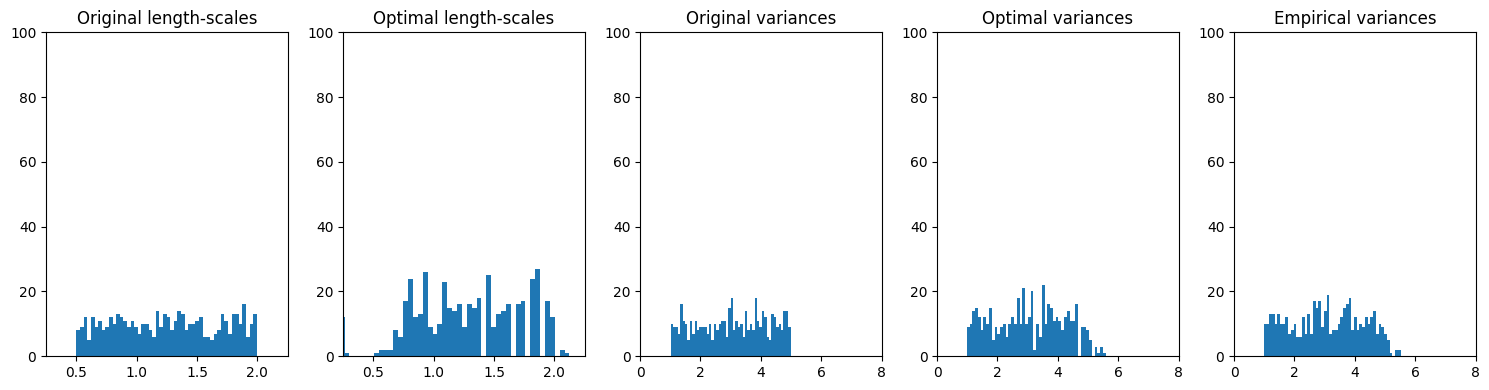

In [34]:
fig, ax = plt.subplots(1, 5, figsize=(15, 4))

ax[0].hist(orig_lss, bins=50)
ax[0].set_title("Original length-scales")
ax[0].set_xlim(kern_priors["length_scale"][0]-.25, kern_priors["length_scale"][-1]+.25)
ax[0].set_ylim(0, 100)

ax[1].hist(opti_lss, bins=50)
ax[1].set_title("Optimal length-scales")
ax[1].set_xlim(kern_priors["length_scale"][0]-.25, kern_priors["length_scale"][-1]+.25)
ax[1].set_ylim(0, 100)

ax[2].hist(orig_vars, bins=50)
ax[2].set_title("Original variances")
ax[2].set_xlim(0., 8.)
ax[2].set_ylim(0, 100)

ax[3].hist(opti_vars, bins=50)
ax[3].set_title("Optimal variances")
ax[3].set_xlim(0., 8.)
ax[3].set_ylim(0, 100)

ax[4].hist(empi_vars, bins=50)
ax[4].set_title("Empirical variances")
ax[4].set_xlim(0., 8.)
ax[4].set_ylim(0, 100)


plt.tight_layout()
plt.show()

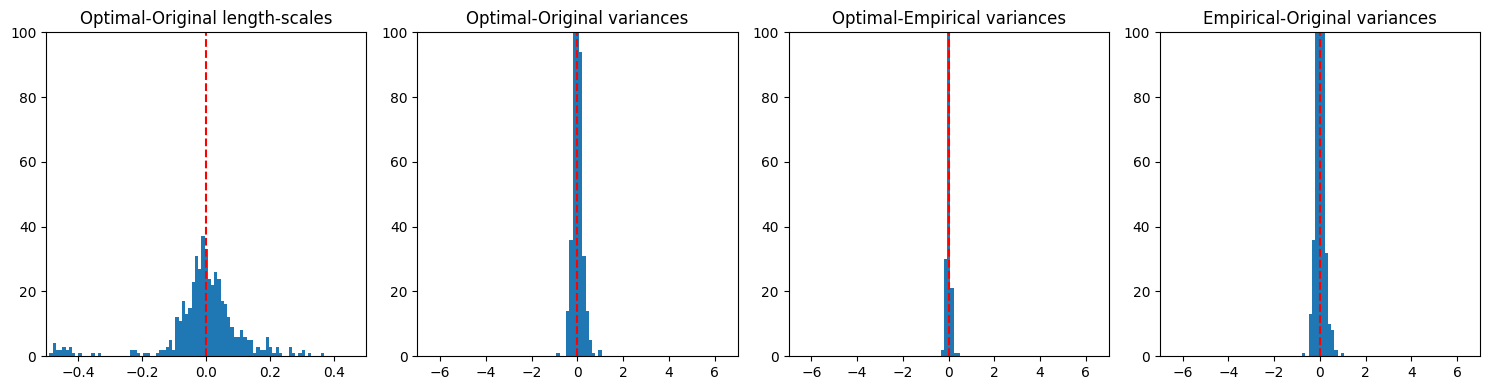

In [35]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

nb_bins = 100
ls_low, ls_high = -.5, .5
vr_low, vr_high = -7, 7
ls_bins = jnp.linspace(ls_low, ls_high, nb_bins)
var_bins = jnp.linspace(vr_low, vr_high, nb_bins)
ls_max = 250
var_max = 100

ax[0].hist(opti_lss - orig_lss, bins=ls_bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original length-scales")
ax[0].set_xlim(ls_low, ls_high)
ax[0].set_ylim(0, 100)

ax[1].hist(opti_vars - orig_vars, bins=var_bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original variances")
ax[1].set_xlim(vr_low, vr_high)
ax[1].set_ylim(0, 100)

ax[2].hist(opti_vars - empi_vars, bins=var_bins)
ax[2].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[2].set_title("Optimal-Empirical variances")
ax[2].set_xlim(vr_low, vr_high)
ax[2].set_ylim(0, 100)

ax[3].hist(empi_vars - orig_vars, bins=var_bins)
ax[3].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[3].set_title("Empirical-Original variances")
ax[3].set_xlim(vr_low, vr_high)
ax[3].set_ylim(0, 100)

plt.tight_layout()
plt.show()

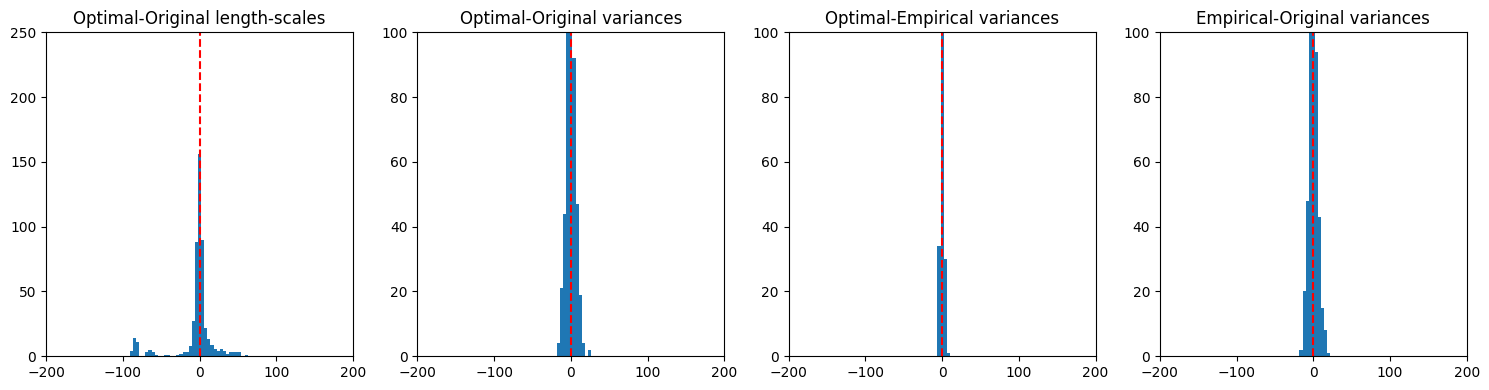

In [36]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

low, high = -200, 200
bins = jnp.linspace(low, high, 100)
ls_max = 250
var_max = 100

ax[0].hist((opti_lss - orig_lss)/orig_lss*100, bins=bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original length-scales")
ax[0].set_xlim(low, high)
ax[0].set_ylim(0, ls_max)

ax[1].hist((opti_vars - orig_vars)/orig_vars*100, bins=bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original variances")
ax[1].set_xlim(low, high)
ax[1].set_ylim(0, var_max)

ax[2].hist((opti_vars - empi_vars)/empi_vars*100, bins=bins)
ax[2].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[2].set_title("Optimal-Empirical variances")
ax[2].set_xlim(low, high)
ax[2].set_ylim(0, var_max)

ax[3].hist((empi_vars - orig_vars)/orig_vars*100, bins=bins)
ax[3].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[3].set_title("Empirical-Original variances")
ax[3].set_xlim(low, high)
ax[3].set_ylim(0, var_max)

plt.tight_layout()
plt.show()

---